# Synthetic Data Generation Pipeline
> Generates a YOLO-formatted dataset by compositing product exemplars onto background images.

## 1. Setup
Install required dependencies for image processing.

In [1]:
!pip install opencv-python tqdm

## 2. Imports

In [2]:
import os
import cv2
import numpy as np
import random
from tqdm import tqdm
import shutil

## 3. Configuration
Set paths for input exemplars, backgrounds, and output directories. Adjust `BACKGROUND_DIR` if your dataset is stored elsewhere.

In [3]:
# INPUT (Kaggle dataset)
INPUT_FOLDER = "/kaggle/input/datasets/mayaralabidi/minimaldataset-automatic-checkout-system/mydataset/exemplars"


# YOUR BACKGROUNDS (IMPORTANT: adjust if needed)
BACKGROUND_DIR = "/kaggle/input/datasets/mayaralabidi/minimaldataset-automatic-checkout-system/mydataset/backgrounds"

# OUTPUT
PROCESSED_DIR = "/kaggle/working/exemplars_processed"
OUTPUT_DIR = "/kaggle/working/data"

## 4. Initialize Directory Structure
Clears any previous output and recreates clean folders for images and labels.

In [4]:
for folder in [PROCESSED_DIR, OUTPUT_DIR]:
    if os.path.exists(folder):
        shutil.rmtree(folder)

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/images", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/labels", exist_ok=True)

print("Clean setup done ✅")

Clean setup done ✅


## 5. Preprocess Exemplars
For each product, extract the RGB image and binary mask from the RGBA `.png` files. Saves them as paired `.jpg` / `_mask.jpg` files.

In [5]:
for product in os.listdir(INPUT_FOLDER):
    product_path = os.path.join(INPUT_FOLDER, product)

    if not os.path.isdir(product_path):
        continue

    output_product_path = os.path.join(PROCESSED_DIR, product)
    os.makedirs(output_product_path, exist_ok=True)

    for file in os.listdir(product_path):
        if file.endswith(".png"):
            path = os.path.join(product_path, file)

            img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

            if img is None or img.shape[2] != 4:
                continue

            rgb = img[:, :, :3]
            alpha = img[:, :, 3]

            mask = (alpha > 0).astype(np.uint8) * 255

            name = file.replace(".png", "")

            cv2.imwrite(f"{output_product_path}/{name}.jpg", rgb)
            cv2.imwrite(f"{output_product_path}/{name}_mask.jpg", mask)

print("Exemplars processed ✅")

Exemplars processed ✅


## 6. Load Exemplars & Backgrounds into Memory
Reads all processed exemplar images alongside their masks, and loads all background images. Assigns a `class_id` to each product folder.


In [6]:
exemplars = []
class_names = []

# Load products
for class_id, product in enumerate(os.listdir(PROCESSED_DIR)):
    product_path = os.path.join(PROCESSED_DIR, product)

    if not os.path.isdir(product_path):
        continue

    class_names.append(product)

    for file in os.listdir(product_path):
        if file.endswith(".jpg") and "_mask" not in file:
            img_path = os.path.join(product_path, file)
            mask_path = img_path.replace(".jpg", "_mask.jpg")

            if os.path.exists(mask_path):
                img = cv2.imread(img_path)
                mask = cv2.imread(mask_path, 0)
                exemplars.append((img, mask, class_id))

# Load backgrounds
backgrounds = []
for file in os.listdir(BACKGROUND_DIR):
    path = os.path.join(BACKGROUND_DIR, file)
    img = cv2.imread(path)

    if img is not None:
        backgrounds.append(img)

print("Classes:", class_names)
print("Exemplars:", len(exemplars))
print("Backgrounds:", len(backgrounds))

Classes: ['judy', 'chantilly_vanoise', 'shampoo_elvive', 'showergel', 'liquidsoap_naya', 'pasta_canelloni', 'milk_delice', 'carolin', 'soap_lilas', 'soapbar_dove_shea', 'bakingpowder', 'orzo', 'cocoapowder', 'choco_coating', 'mustard', 'harissa', 'canned_peas', 'shampoo_elseve_hya', 'yogurt_delice', 'shampoo_elseve_gly', 'choc', 'bathfoam_malizia', 'pril', 'coffee_bondin', 'disinfectant_cnett', 'vanillinatedsugar', 'chocoline', 'rice', 'teabags_camomilia', 'conditioner_avilea', 'butter_delice', 'pasta_spaghetti', 'pasta_fell', 'choco_esprit_de_fete', 'riso_scotti', 'juice_diva', 'yogurt_danette', 'dryyeast_smartchef', 'toothpaste_colgate', 'chocospread_vanoise', 'vinegar', 'flour', 'soapbar_dove_lavender', 'dryyeast_lapatissiere', 'butter_jadida']
Exemplars: 296
Backgrounds: 6


## 7. Synthetic Image Generation
Composites 3–7 randomly scaled and placed product exemplars onto a random background. Writes the image and a YOLO-format label file (normalized bounding boxes) for each synthetic scene.

> **Parameters:**
> - `num_objects`: 3–7 per image
> - `scale`: 0.4–1.0×
> - Output resolution: 720×720

In [7]:
def generate_image(idx):
    bg = random.choice(backgrounds).copy()
    bg = cv2.resize(bg, (720, 720))

    h_bg, w_bg = bg.shape[:2]

    num_objects = random.randint(3, 7)
    labels = []

    for _ in range(num_objects):
        img, mask, class_id = random.choice(exemplars)

        scale = random.uniform(0.4, 1.0)
        img = cv2.resize(img, None, fx=scale, fy=scale)
        mask = cv2.resize(mask, None, fx=scale, fy=scale)

        h, w = img.shape[:2]

        if h >= h_bg or w >= w_bg:
            continue

        x = random.randint(0, w_bg - w)
        y = random.randint(0, h_bg - h)

        roi = bg[y:y+h, x:x+w]

        mask_bool = mask > 127
        roi[mask_bool] = img[mask_bool]

        xc = (x + w/2) / w_bg
        yc = (y + h/2) / h_bg
        wn = w / w_bg
        hn = h / h_bg

        labels.append(f"{class_id} {xc} {yc} {wn} {hn}")

    cv2.imwrite(f"{OUTPUT_DIR}/images/{idx}.jpg", bg)

    with open(f"{OUTPUT_DIR}/labels/{idx}.txt", "w") as f:
        f.write("\n".join(labels))


for i in tqdm(range(2000)):
    generate_image(i)

print("Synthetic dataset generated ✅")

100%|██████████| 2000/2000 [00:38<00:00, 52.60it/s]

Synthetic dataset generated ✅


## 8. Export `data.yaml`
Creates the YOLO dataset config file pointing to the generated images/labels.

In [8]:
yaml_content = f"""
path: /kaggle/working/data
train: images
val: images

nc: {len(class_names)}
names: {class_names}
"""

with open("data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created ✅")

data.yaml created ✅


## 9. Exploratory Data Analysis
Inspect the generated dataset before training — check class balance, bounding box geometry, and visual quality.

### 9.1 Imports

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import Counter
import random, os, cv2, numpy as np

### 9.2 Class distribution
Count bounding box instances per class across all label files. A healthy dataset has no class with zero instances.

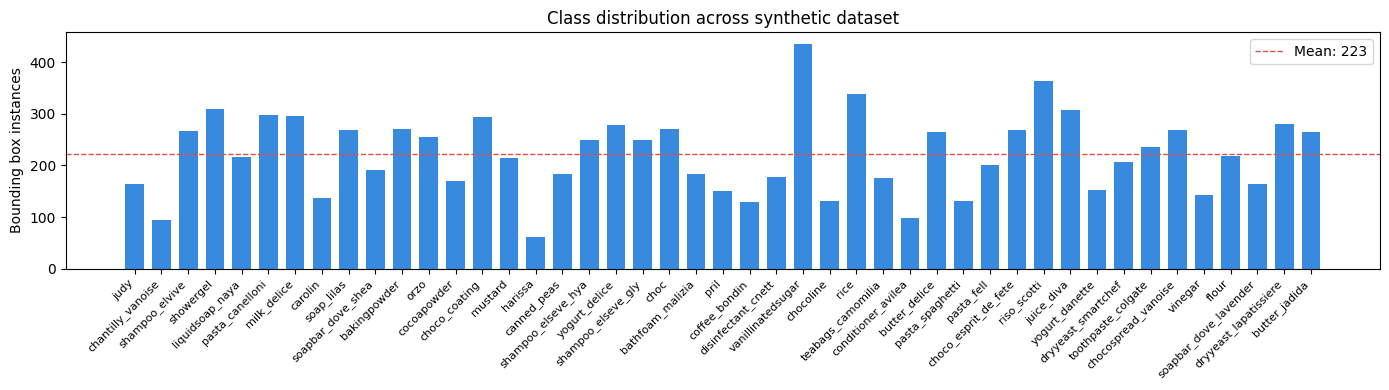

Total classes   : 45
Total instances : 10027
Min             : 62 (harissa)
Max             : 436 (vanillinatedsugar)


In [10]:
class_counts = Counter()

for fname in os.listdir(f"{OUTPUT_DIR}/labels"):
    with open(f"{OUTPUT_DIR}/labels/{fname}") as f:
        for line in f:
            if line.strip():
                cls = int(line.split()[0])
                class_counts[cls] += 1

names  = [class_names[i] for i in sorted(class_counts)]
counts = [class_counts[i] for i in sorted(class_counts)]

fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(range(len(names)), counts, color="#378ADD", width=0.7)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Bounding box instances")
ax.set_title("Class distribution across synthetic dataset")
ax.axhline(np.mean(counts), color="#E24B4A", linestyle="--",
           linewidth=1, label=f"Mean: {np.mean(counts):.0f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Total classes   : {len(class_counts)}")
print(f"Total instances : {sum(counts)}")
print(f"Min             : {min(counts)} ({names[counts.index(min(counts))]})")
print(f"Max             : {max(counts)} ({names[counts.index(max(counts))]})")

### 9.3 Objects per image
Distribution of how many objects appear in each synthetic scene. Should peak around 3–7 (our generation range).

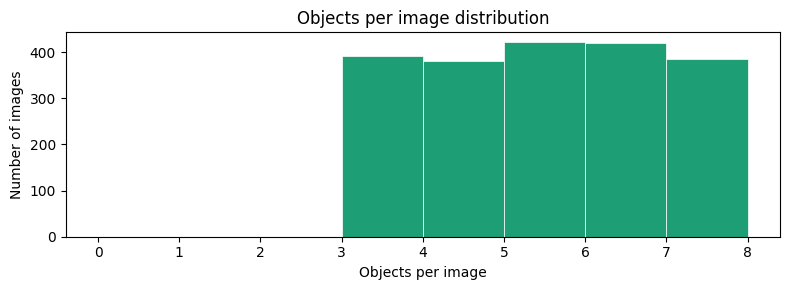

Mean objects/image : 5.01
Images with 0 objs : 0


In [11]:
obj_counts = []

for fname in os.listdir(f"{OUTPUT_DIR}/labels"):
    with open(f"{OUTPUT_DIR}/labels/{fname}") as f:
        lines = [l for l in f if l.strip()]
        obj_counts.append(len(lines))

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(obj_counts, bins=range(0, max(obj_counts)+2), color="#1D9E75",
        edgecolor="white", linewidth=0.5)
ax.set_xlabel("Objects per image")
ax.set_ylabel("Number of images")
ax.set_title("Objects per image distribution")
plt.tight_layout()
plt.show()

print(f"Mean objects/image : {np.mean(obj_counts):.2f}")
print(f"Images with 0 objs : {obj_counts.count(0)}")

### 9.4 Bounding box geometry
Check width, height, and aspect ratio distributions. Extreme values indicate compositing issues (objects too large/small or incorrectly stretched).

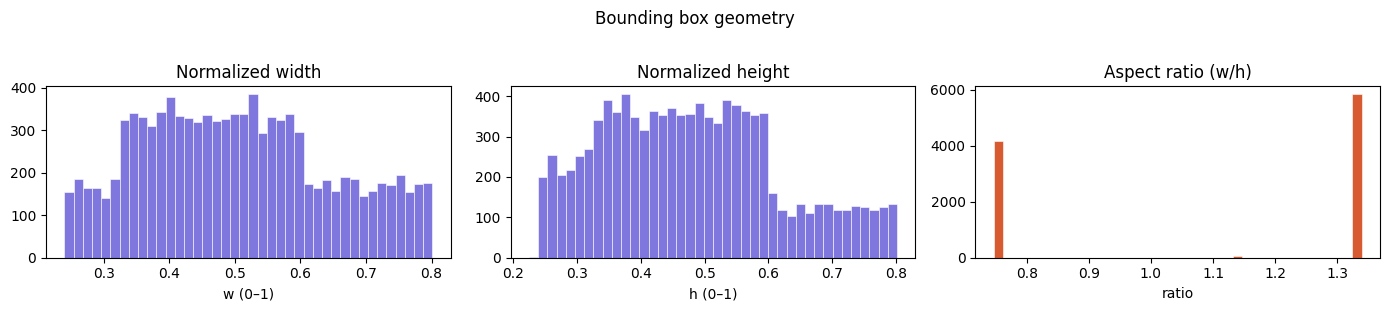

Avg box w : 0.503  |  h : 0.479
Out-of-bounds (w or h > 1): 0


In [12]:
widths, heights, aspects = [], [], []

for fname in os.listdir(f"{OUTPUT_DIR}/labels"):
    with open(f"{OUTPUT_DIR}/labels/{fname}") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                _, xc, yc, w, h = map(float, parts)
                widths.append(w)
                heights.append(h)
                aspects.append(w / h if h > 0 else 0)

fig, axes = plt.subplots(1, 3, figsize=(14, 3))

axes[0].hist(widths,  bins=40, color="#7F77DD", edgecolor="white", linewidth=0.4)
axes[0].set_title("Normalized width")
axes[0].set_xlabel("w (0–1)")

axes[1].hist(heights, bins=40, color="#7F77DD", edgecolor="white", linewidth=0.4)
axes[1].set_title("Normalized height")
axes[1].set_xlabel("h (0–1)")

axes[2].hist(aspects, bins=40, color="#D85A30", edgecolor="white", linewidth=0.4)
axes[2].set_title("Aspect ratio (w/h)")
axes[2].set_xlabel("ratio")

plt.suptitle("Bounding box geometry", y=1.02)
plt.tight_layout()
plt.show()

print(f"Avg box w : {np.mean(widths):.3f}  |  h : {np.mean(heights):.3f}")
print(f"Out-of-bounds (w or h > 1): {sum(1 for w,h in zip(widths,heights) if w>1 or h>1)}")

### 9.5 Sanity check — out-of-bounds boxes
YOLO requires all coordinates in [0, 1]. Any violation here means a compositing bug.

In [13]:
bad = []

for fname in os.listdir(f"{OUTPUT_DIR}/labels"):
    fpath = f"{OUTPUT_DIR}/labels/{fname}"
    with open(fpath) as f:
        for i, line in enumerate(f):
            parts = line.strip().split()
            if len(parts) == 5:
                _, xc, yc, w, h = map(float, parts)
                if not (0 <= xc <= 1 and 0 <= yc <= 1 and 0 < w <= 1 and 0 < h <= 1):
                    bad.append((fname, i, xc, yc, w, h))

if bad:
    print(f"⚠️  {len(bad)} invalid boxes found:")
    for b in bad[:10]:
        print(f"   {b}")
else:
    print("✅ All bounding boxes are valid (coordinates in [0, 1])")

✅ All bounding boxes are valid (coordinates in [0, 1])


### 9.6 Visual spot check
Draw bounding boxes on a random sample of generated images to confirm compositing looks correct.

/tmp/ipykernel_22/1404134316.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  COLORS = plt.cm.get_cmap("tab20", len(class_names)).colors


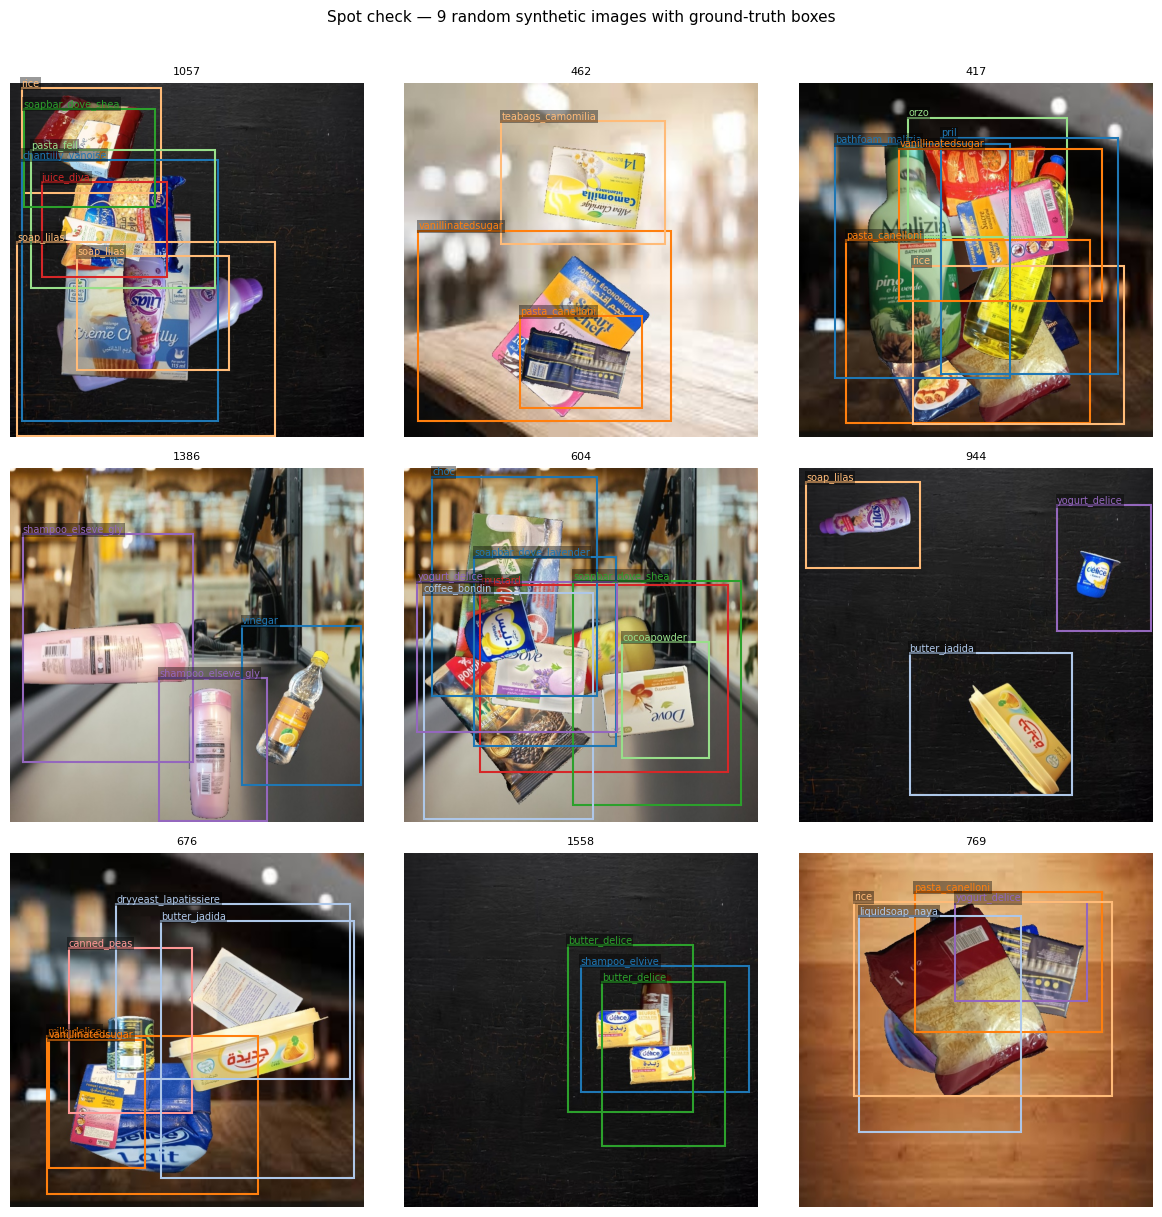

In [14]:
COLORS = plt.cm.get_cmap("tab20", len(class_names)).colors

sample_files = random.sample(os.listdir(f"{OUTPUT_DIR}/images"), 9)
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, fname in zip(axes.flat, sample_files):
    stem   = fname.replace(".jpg", "")
    img    = cv2.cvtColor(cv2.imread(f"{OUTPUT_DIR}/images/{fname}"), cv2.COLOR_BGR2RGB)
    h, w   = img.shape[:2]
    ax.imshow(img)

    label_path = f"{OUTPUT_DIR}/labels/{stem}.txt"
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls, xc, yc, bw, bh = int(parts[0]), *map(float, parts[1:])
                    x1 = (xc - bw/2) * w
                    y1 = (yc - bh/2) * h
                    rect = patches.Rectangle(
                        (x1, y1), bw*w, bh*h,
                        linewidth=1.5, edgecolor=COLORS[cls % 20], facecolor="none"
                    )
                    ax.add_patch(rect)
                    ax.text(x1, y1 - 4, class_names[cls],
                            fontsize=7, color=COLORS[cls % 20],
                            bbox=dict(fc="black", alpha=0.4, pad=1, lw=0))

    ax.axis("off")
    ax.set_title(stem, fontsize=8)

plt.suptitle("Spot check — 9 random synthetic images with ground-truth boxes",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()